# Question 1: Watts–Strogatz Small-World Network Model

The WS model creates networks with small-world properties by starting with a regular ring lattice and randomly rewiring edges with probability $p$.

As $p$ goes from 0 to 1, the network transitions from regular → small-world → random.

We compute the **scaled clustering coefficient** $C(p)/C(0)$ and **scaled characteristic path length** $L(p)/L(0)$ to capture this transition.

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

def watts_strogatz_manual(n, k, p):
    G = nx.Graph()
    nodes = list(range(n))
    G.add_nodes_from(nodes)

    # Step 1: Create regular ring lattice
    for i in range(n):
        for j in range(1, k//2 + 1):
            G.add_edge(i, (i + j) % n)

    # Step 2: Rewire edges with probability p
    for i in range(n):
        for j in range(1, k//2 + 1):
            if np.random.rand() < p:
                neighbor = (i + j) % n

                # Remove existing edge
                if G.has_edge(i, neighbor):
                    G.remove_edge(i, neighbor)

                # Add new edge avoiding self-loops & duplicates
                new_node = np.random.choice(nodes)
                while new_node == i or G.has_edge(i, new_node):
                    new_node = np.random.choice(nodes)

                G.add_edge(i, new_node)

    return G

## Computing Scaled Metrics

Parameters: $n = 1000$, $k = 10$, $p$ from $10^{-4}$ to $1$ (log scale, 20 points). Each value of $p$ averaged over 10 runs.

First we get $C(0)$ and $L(0)$ at $p=0$ (regular lattice) as baselines.

In [2]:
def compute_metrics(G):
    # Clustering coefficient
    C = nx.average_clustering(G)

    # Characteristic path length
    if nx.is_connected(G):
        L = nx.average_shortest_path_length(G)
    else:
        # Use largest connected component
        Gcc = G.subgraph(max(nx.connected_components(G), key=len))
        L = nx.average_shortest_path_length(Gcc)

    return C, L

n = 1000     # large n captures small-world behavior
k = 10      # k << n ensures sparse network

# Log-scale probabilities (important!)
p_values = np.logspace(-4, 0, 20)

G0 = watts_strogatz_manual(n, k, 0)
C0, L0 = compute_metrics(G0)

print("C(0):", C0)
print("L(0):", L0)

C(0): 0.6666666666666666
L(0): 50.450450450450454


In [3]:
C_vals = []
L_vals = []

runs = 10

for p in p_values:
    C_temp = []
    L_temp = []

    for _ in range(runs):
        G = watts_strogatz_manual(n, k, p)
        C, L = compute_metrics(G)

        C_temp.append(C)
        L_temp.append(L)

    # Take average
    C_avg = np.mean(C_temp)
    L_avg = np.mean(L_temp)

    C_vals.append(C_avg / C0)
    L_vals.append(L_avg / L0)

    print(f"p={p:.5f} | C/C0={C_avg/C0:.3f} | L/L0={L_avg/L0:.3f}")

p=0.00010 | C/C0=1.000 | L/L0=0.932
p=0.00016 | C/C0=0.999 | L/L0=0.792
p=0.00026 | C/C0=0.999 | L/L0=0.846
p=0.00043 | C/C0=0.999 | L/L0=0.866
p=0.00070 | C/C0=0.998 | L/L0=0.633
p=0.00113 | C/C0=0.997 | L/L0=0.529
p=0.00183 | C/C0=0.994 | L/L0=0.384
p=0.00298 | C/C0=0.992 | L/L0=0.326
p=0.00483 | C/C0=0.986 | L/L0=0.247
p=0.00785 | C/C0=0.980 | L/L0=0.207
p=0.01274 | C/C0=0.964 | L/L0=0.162
p=0.02069 | C/C0=0.937 | L/L0=0.133
p=0.03360 | C/C0=0.909 | L/L0=0.118
p=0.05456 | C/C0=0.851 | L/L0=0.102
p=0.08859 | C/C0=0.769 | L/L0=0.091
p=0.14384 | C/C0=0.637 | L/L0=0.082
p=0.23357 | C/C0=0.455 | L/L0=0.074
p=0.37927 | C/C0=0.248 | L/L0=0.069
p=0.61585 | C/C0=0.069 | L/L0=0.066
p=1.00000 | C/C0=0.014 | L/L0=0.065


## Plot: Scaled C(p)/C(0) and L(p)/L(0)

Replicating the classic WS plot — x-axis is $p$ on log scale, y-axis is the normalized metrics.

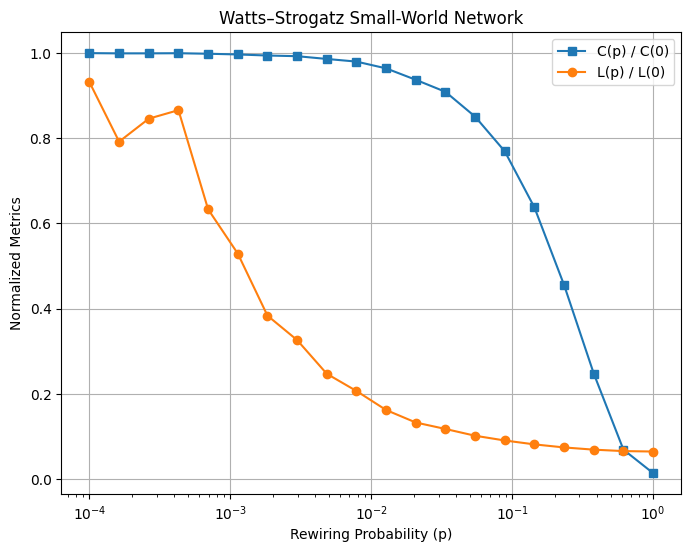

Figure saved: ws_scaled_metrics.png


In [4]:
plt.figure(figsize=(8,6))

# Clustering coefficient
plt.semilogx(p_values, C_vals, 's-', label='C(p) / C(0)')

# Path length
plt.semilogx(p_values, L_vals, 'o-', label='L(p) / L(0)')

plt.xlabel('Rewiring Probability (p)')
plt.ylabel('Normalized Metrics')
plt.title('Watts–Strogatz Small-World Network')

plt.legend()
plt.grid(True)

plt.savefig('ws_scaled_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: ws_scaled_metrics.png")

## Network Visualisation

Small examples ($n=30, k=4$) showing the structural change as $p$ increases.

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def circular_layout(n):
    angles = [2 * np.pi * i / n for i in range(n)]
    return {i: (np.cos(a), np.sin(a)) for i, a in enumerate(angles)}

def draw_ws_circular(ax, G, title, n):
    pos = circular_layout(n)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=13, pad=10)
    for u, v in G.edges():
        ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
                color='black', linewidth=0.7, zorder=1, alpha=0.8)
    ax.scatter([pos[i][0] for i in range(n)], [pos[i][1] for i in range(n)],
               s=80, color='black', zorder=2)
    ax.set_xlim(-1.25, 1.25)
    ax.set_ylim(-1.25, 1.25)

n_vis, k_vis = 20, 4
G_reg  = watts_strogatz_manual(n_vis, k_vis, 0)
G_sw   = watts_strogatz_manual(n_vis, k_vis, 0.15)
G_rand = watts_strogatz_manual(n_vis, k_vis, 1)

fig = plt.figure(figsize=(13, 5.5))
ax1 = fig.add_axes([0.02, 0.18, 0.30, 0.72])
ax2 = fig.add_axes([0.35, 0.18, 0.30, 0.72])
ax3 = fig.add_axes([0.68, 0.18, 0.30, 0.72])
draw_ws_circular(ax1, G_reg,  'Regular',     n_vis)
draw_ws_circular(ax2, G_sw,   'Small-world', n_vis)
draw_ws_circular(ax3, G_rand, 'Random',      n_vis)

ax_arrow = fig.add_axes([0.05, 0.04, 0.90, 0.08])
ax_arrow.axis('off')
ax_arrow.set_xlim(0, 1)
ax_arrow.set_ylim(0, 1)

# arrow starts/ends away from labels so nothing overlaps
ax_arrow.annotate('', xy=(0.90, 0.65), xytext=(0.10, 0.65),
    arrowprops=dict(arrowstyle='->', color='black', lw=1.4))
ax_arrow.text(0.04, 0.65, '$p = 0$',         ha='center', va='center', fontsize=11)
ax_arrow.text(0.96, 0.65, '$p \\approx 1$', ha='center', va='center', fontsize=11)
ax_arrow.text(0.50, 0.05, 'Increasing randomness', ha='center', va='bottom', fontsize=11)

plt.savefig('ws_network_visualisation.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Figure saved: ws_network_visualisation.png")


## Interpretation

- At $p=0$: high clustering ($C(0) \approx 0.67$) but long paths ($L(0) \approx 50.5$).
- $L$ drops fast with even small $p$ — a few random shortcuts go a long way.
- $C$ stays high until around $p \approx 0.1$ since most edges remain local.
- The small-world regime is roughly $0.01 \lesssim p \lesssim 0.1$ where $L$ is already low but $C$ is still high.